# Задача 7. Нейронные сети

## Задача

- [x] Найти данные в виде изображений для задачи классификации. Например, можно взять данные [отсюда](http://ufldl.stanford.edu/housenumbers/).
- [x] Реализовать классы, необходимые для построения сети со следующими слоями
	- FullyConnectedLayer
	- ReluLayer
	- FullyConnectedLayer
- [x] Использовать CrossEntropyLoss и L2-регуляризацию.
- [x] Обучить модель на тренировочных данных, подбирать параметры (особенно learning rate) на валидационной и оценить качество на тестовой. Анализировать графики train/val loss, проверять на каждом шаге корректность вычисления градиентов с помощью разностной оценки.
- [x] * (**+2 балла**) Добавить Batch normalization.
- [x] * (**+2 балла**) В качестве оптимизатор использовать один из: Momentum, RMSprop.
- [x] * (**+1 балл**) Также реализовать оптимизатор Adam.

# Датасет

В качестве датасета использован [Hindi-MNIST](https://www.kaggle.com/datasets/imbikramsaha/hindi-mnist) - набор данных, содержащий изображения рукописных цифр на языке хинди. Датасет содержит 20 000 изображений 10 категорий: 17 000 в `train` и 3000 в `test`.  
Скачаем и нормализуем его.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub
%matplotlib inline


RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset_path = kagglehub.dataset_download("imbikramsaha/hindi-mnist")

# Dataset paths for Hindi-MNIST
train_dir = os.path.join(dataset_path, "Hindi-MNIST", "train")
test_dir  = os.path.join(dataset_path, "Hindi-MNIST", "test")

# Transforms: convert to grayscale and normalize
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),   # ensure 1-channel
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset  = datasets.ImageFolder(root=test_dir,  transform=transform)

print("Number of training images:", len(train_dataset))
print("Number of testing images:", len(test_dataset))

/home/maxim/ml-course/solutions/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Number of training images: 17000
Number of testing images: 3000


Визуализируем по одному примеру каждого класса, чтобы понять визуальную природу данных.

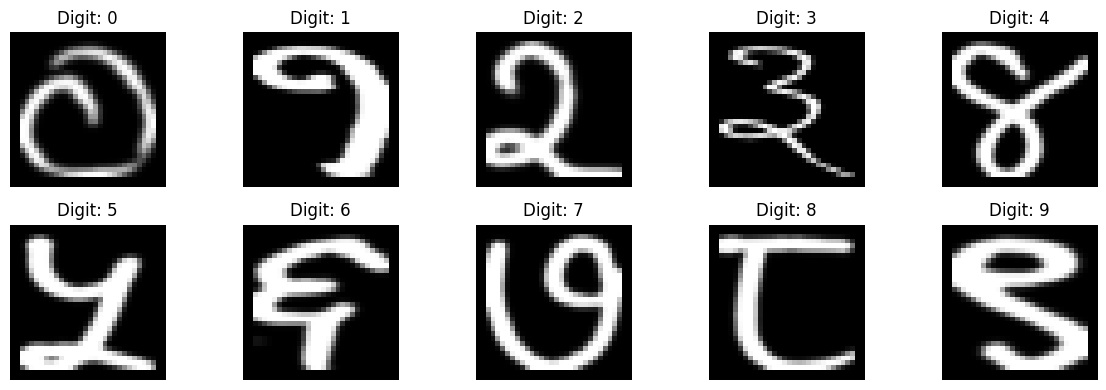

In [2]:
samples = {}

# Iterate through training dataset until we collect all digits
for img, label in train_dataset:
    if label not in samples:
        samples[label] = img
    if len(samples) == 10:
        break

plt.figure(figsize=(12, 4))

for digit in range(10):
    plt.subplot(2, 5, digit + 1)
    plt.imshow(samples[digit].squeeze(), cmap='gray')
    plt.title(f"Digit: {digit}")
    plt.axis('off')

plt.tight_layout()

## Архитектура нейронной сети

### Слои для нейронной сети

Реализуем три ключевых класса:

- `FullyConnectedLayer`
- `ReluLayer`
- `BatchNormLayer`

In [3]:
class FullyConnectedLayer(nn.Module):
    def __init__(self, in_num: int, out_num: int) -> None:
        super().__init__()
        a = 1 / np.sqrt(in_num / 2)
        self.weight = nn.Parameter(a * torch.randn(in_num, out_num))
        self.bias = nn.Parameter(torch.zeros(out_num))

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        self.X = X
        return torch.matmul(X, self.weight) + self.bias


class ReluLayer(nn.Module):
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return X * (X > 0).float()


class BatchNormLayer(nn.Module):
    def __init__(
        self, num_features: int, eps: float = 1e-5, momentum: float = 0.1
    ) -> None:
        super().__init__()
        self.eps = eps
        self.momentum = momentum
        self.weight = nn.Parameter(torch.ones(num_features))
        self.bias = nn.Parameter(torch.zeros(num_features))
        self.register_buffer("running_mean", torch.zeros(num_features))
        self.register_buffer("running_var", torch.ones(num_features))
        self.register_buffer(
            "num_batches_tracked", torch.tensor(0, dtype=torch.long)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            mean = x.mean(dim=0)
            var = x.var(dim=0, unbiased=False)

            with torch.no_grad():
                self.running_mean.copy_(
                    (1 - self.momentum) * self.running_mean + self.momentum * mean
                )
                self.running_var.copy_(
                    (1 - self.momentum) * self.running_var + self.momentum * var
                )
                self.num_batches_tracked += 1
        else:
            mean = self.running_mean
            var = self.running_var

        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return x_norm * self.weight + self.bias

### Нейронная сеть

Сеть содержит один скрытый полносвязный слой и один выходной полносвязный слой:

```
Input → FC1 → [BatchNorm] → ReLU → FC2 → Output
```

Батч-нормализация вставляется опционально между первым линейным слоем и активацией.

In [4]:
class NeuralNetwork(nn.Module):
    def __init__(
        self,
        input_size: int = 1024,
        hidden_size: int = 128,
        batch_norm: bool = False,
    ) -> None:
        super().__init__()
        self.batch_norm = batch_norm

        self.fc1 = FullyConnectedLayer(input_size, hidden_size)
        self.relu1 = ReluLayer()
        self.bn1 = BatchNormLayer(hidden_size) if batch_norm else None
        self.fc2 = FullyConnectedLayer(hidden_size, 10)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        X = X.view(X.size(0), -1)

        X = self.fc1(X)
        if self.batch_norm:
            X = self.bn1(X)
        X = self.relu1(X)
        X = self.fc2(X)
        return X

### Оптимизатор Adam

Реализуем оптимизатор Adam с поддержкой L2-регуляризации.

In [5]:
class AdamOptimizer:
    def __init__(
        self,
        params,
        lr: float = 1e-3,
        betas: tuple[float, float] = (0.9, 0.999),
        eps: float = 1e-8,
        weight_decay: float = 0.0,
    ):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0

        self.m = {p: torch.zeros_like(p) for p in self.params}
        self.v = {p: torch.zeros_like(p) for p in self.params}

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def step(self):
        self.t += 1

        for p in self.params:
            if p.grad is None:
                continue

            grad = p.grad.data

            if self.weight_decay != 0:
                grad = grad + self.weight_decay * p.data

            self.m[p] = self.beta1 * self.m[p] + (1 - self.beta1) * grad
            self.v[p] = self.beta2 * self.v[p] + (1 - self.beta2) * grad**2

            m_hat = self.m[p] / (1 - self.beta1**self.t)
            v_hat = self.v[p] / (1 - self.beta2**self.t)

            p.data -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

## Проверка градиентов

Для верификации корректности обратного распространения реализуем численную проверку градиентов методом конечных разностей.

In [6]:
from typing import Callable


def gradient_check(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    criterion: Callable,
    eps: float = 1e-5,
    atol: float = 1e-3,
    n_checks_per_param: int = 20,
) -> bool:
    model.double().eval()
    X = X.double()

    def loss_fn():
        return criterion(model(X), y)

    model.zero_grad()
    loss_fn().backward()

    all_ok = True
    for name, param in model.named_parameters():
        if param.grad is None:
            continue

        analytical_grad = param.grad.data.clone()
        numerical_grad = torch.zeros_like(param.data)

        flat_param = param.data.view(-1)
        flat_num = numerical_grad.view(-1)
        n_check = min(n_checks_per_param, flat_param.numel())
        indices = torch.randperm(flat_param.numel())[:n_check]

        for idx in indices:
            orig = flat_param[idx].item()

            flat_param[idx] = orig + eps
            with torch.no_grad():
                loss_plus = loss_fn().item()

            flat_param[idx] = orig - eps
            with torch.no_grad():
                loss_minus = loss_fn().item()

            flat_param[idx] = orig
            flat_num[idx] = (loss_plus - loss_minus) / (2 * eps)

        ag = analytical_grad.view(-1)[indices]
        ng = numerical_grad.view(-1)[indices]

        diff = torch.norm(ag - ng) / (torch.norm(ag) + torch.norm(ng) + 1e-7)
        if diff.item() > atol:
            print(f"  [Grad check] WARNING: {name} failed (err={diff.item():.2e})")
            all_ok = False

    if all_ok:
        print("  [Grad check] Gradients OK")

    model.float().train()
    return all_ok

## Обучение

Функция `train` реализует цикл обучения с несколькими особенностями:

- В конце обучения восстанавливаются веса эпохи с минимальным валидационным лоссом (чтобы минимизировать переобучение);
- На каждой эпохе выводятся train/val loss и accuracy, а также отмечается улучшение валидационного лосса (✓).

In [7]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


def train(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    n_epochs=10,
    grad_check_every=1,
    grad_check_batch=None,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_loss = float("inf")
    best_weights = None

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_weights = {
                k: v.cpu().clone() for k, v in model.state_dict().items()
            }

        print(
            f"Epoch {epoch:3d}/{n_epochs} | "
            f"Train loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | "
            f"Val   loss: {va_loss:.4f}  acc: {va_acc:.4f}"
            + (" ✓" if va_loss == best_val_loss else "")
        )

        if epoch % grad_check_every == 0 and grad_check_batch is not None:
            X_chk, y_chk = grad_check_batch
            X_chk, y_chk = X_chk.to(device), y_chk.to(device)
            grad_ok = gradient_check(model, X_chk, y_chk, criterion)

    # Recovering best weights before returning
    model.load_state_dict(best_weights)
    print(f"\nRestored best weights (val loss = {best_val_loss:.4f})")

    return history, grad_ok

## Код построения диаграмм

In [8]:
def plot_history(history, title=""):
    _, axes = plt.subplots(1, 2, figsize=(14, 4))

    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="Train loss")
    axes[0].plot(epochs, history["val_loss"], label="Val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"Loss — {title}")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, history["train_acc"], label="Train acc")
    axes[1].plot(epochs, history["val_acc"], label="Val acc")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"Accuracy — {title}")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()

In [ ]:
def plot_all_results(results):
    n = len(results)
    cols = 5
    rows = (n + cols - 1) // cols

    _, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = axes.flatten()

    for i, r in enumerate(sorted(results, key=lambda x: x["best_val_loss"])):
        epochs = range(1, len(r["history"]["train_loss"]) + 1)
        axes[i].plot(epochs, r["history"]["train_loss"], label="Train")
        axes[i].plot(epochs, r["history"]["val_loss"], label="Val")
        axes[i].set_title(r["label"], fontsize=8)
        axes[i].set_xlabel("Epoch", fontsize=7)
        axes[i].set_ylabel("Loss", fontsize=7)
        axes[i].legend(fontsize=6)
        axes[i].grid(True)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Train / Val Loss for all configurations", fontsize=12, y=1.02)
    plt.tight_layout()

## Разбивка выборки

Исходная тренировочная выборка делится на train и validation в соотношении 85/15. Из 17 000 тренировочных примеров 2 550 отправляются в валидационную выборку, оставшиеся 14 450 - в тренировочную.  
Данные оборачиваются в DataLoader с размером батча 64.  
Отдельно извлекается фиксированный мини-батч из 16 примеров (`gc_batch`) для периодической проверки градиентов в процессе обучения.

In [ ]:
val_size = int(0.15 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)

test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

gc_images, gc_labels = next(iter(val_loader))
gc_batch = (gc_images[:16], gc_labels[:16])

## Перебор гиперпараметров

Был проведён перебор по сетке из 36 конфигураций:

| Гиперпараметр        | Значения                   |
|----------------------|----------------------------|
| Оптимизатор          | Adam, SGD+MomentumLearning |
| rate                 | 0.01, 0.001, 0.0001        |
| Размер скрытого слоя | 64, 128, 256               |
| Batch Normalization  | Да, Нет                    |

Для каждой конфигурации модель обучалась 10 эпох, затем оценивалась на тестовой выборке с лучшими весами по валидации.

[1/36] no BN | adam | lr=0.01 | hidden=64
[2/36] BN | adam | lr=0.01 | hidden=64
[3/36] no BN | adam | lr=0.01 | hidden=128
[4/36] BN | adam | lr=0.01 | hidden=128
[5/36] no BN | adam | lr=0.01 | hidden=256
[6/36] BN | adam | lr=0.01 | hidden=256
[7/36] no BN | adam | lr=0.001 | hidden=64
[8/36] BN | adam | lr=0.001 | hidden=64
[9/36] no BN | adam | lr=0.001 | hidden=128
[10/36] BN | adam | lr=0.001 | hidden=128
[11/36] no BN | adam | lr=0.001 | hidden=256
[12/36] BN | adam | lr=0.001 | hidden=256
[13/36] no BN | adam | lr=0.0001 | hidden=64
[14/36] BN | adam | lr=0.0001 | hidden=64
[15/36] no BN | adam | lr=0.0001 | hidden=128
[16/36] BN | adam | lr=0.0001 | hidden=128
[17/36] no BN | adam | lr=0.0001 | hidden=256
[18/36] BN | adam | lr=0.0001 | hidden=256
[19/36] no BN | momentum | lr=0.01 | hidden=64
[20/36] BN | momentum | lr=0.01 | hidden=64
[21/36] no BN | momentum | lr=0.01 | hidden=128
[22/36] BN | momentum | lr=0.01 | hidden=128
[23/36] no BN | momentum | lr=0.01 | hidden=256


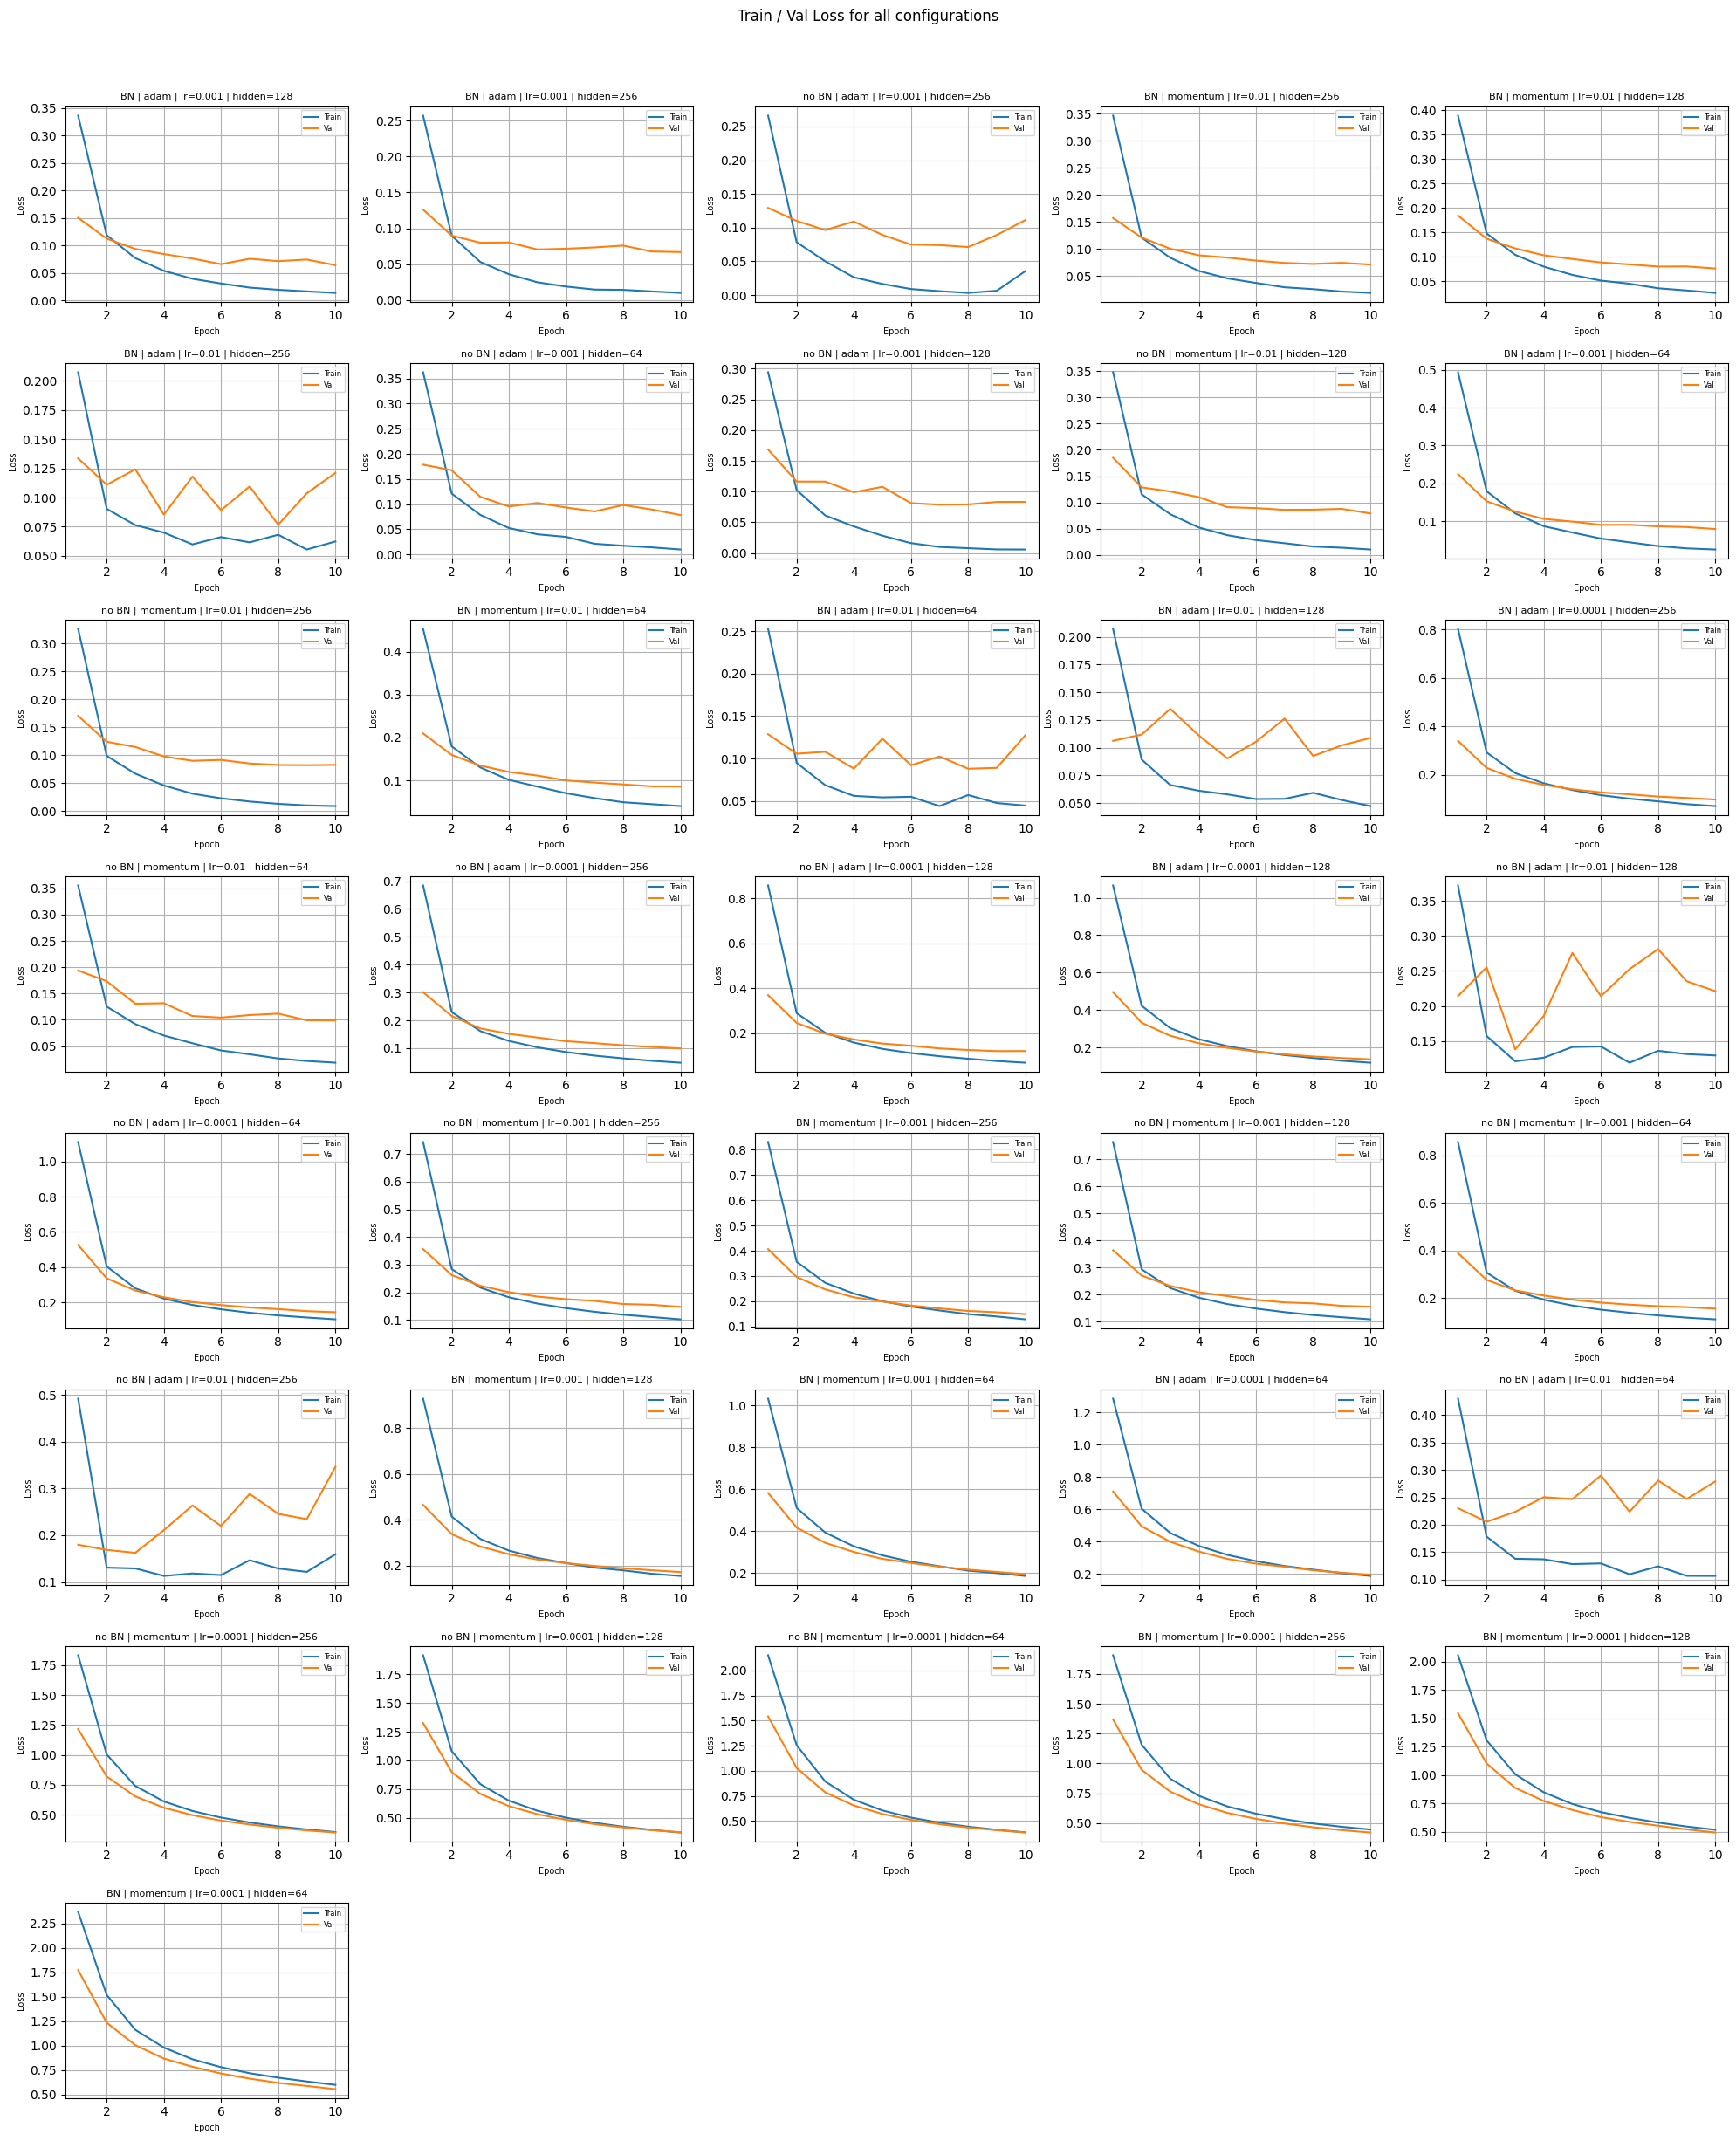


Best config: BN | adam | lr=0.001 | hidden=128


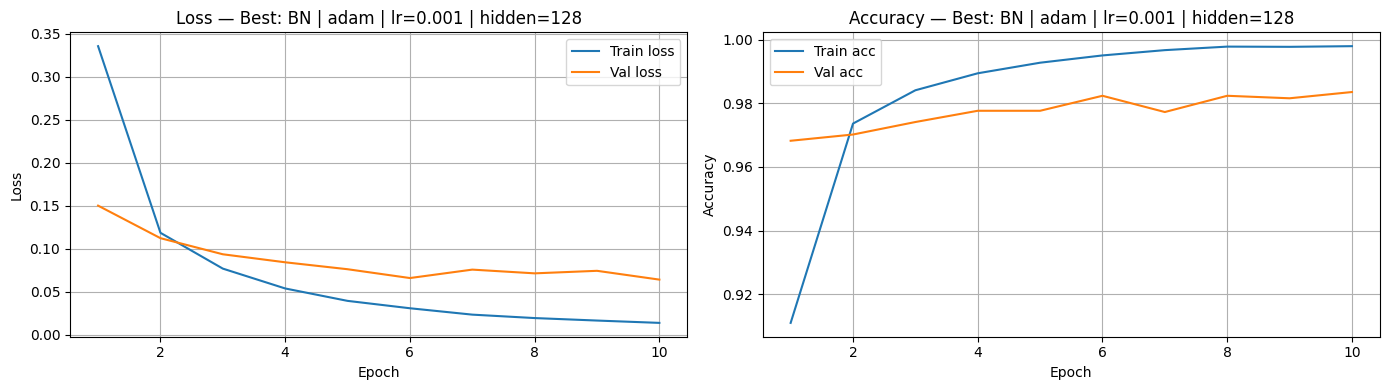

In [ ]:
import itertools
import sys


def run_hyperparameter_search(
    train_loader,
    val_loader,
    test_loader,
    device,
    n_epochs=10,
    log_file="task7_search_log.txt",
):
    optimizers_map = {
        "adam": lambda params, lr: AdamOptimizer(params, lr=lr, weight_decay=1e-4),
        "momentum": lambda params, lr: optim.SGD(
            params, lr=lr, momentum=0.9, weight_decay=1e-4
        ),
    }

    params = [
        {"optim": opt_name, "lr": lr, "hidden_size": hidden_size, "batch_norm": bn}
        for opt_name, lr, hidden_size, bn in itertools.product(
            ["adam", "momentum"],
            [0.01, 0.001, 0.0001],
            [64, 128, 256],
            [False, True],
        )
    ]

    criterion = nn.CrossEntropyLoss()
    results = []

    # Redirect stdout to a file
    original_stdout = sys.stdout
    log = open(log_file, "w", buffering=1)
    sys.stdout = log

    try:
        for i, cfg in enumerate(params):
            opt_name, lr, hidden_size, bn = (
                cfg["optim"],
                cfg["lr"],
                cfg["hidden_size"],
                cfg["batch_norm"],
            )
            label = f"{'BN' if bn else 'no BN'} | {opt_name} | lr={lr} | hidden={hidden_size}"

            print(f"[{i+1}/{len(params)}] {label}", file=original_stdout, flush=True)
            print(f"\n{'='*60}\n[{i+1}/{len(params)}] {label}\n{'='*60}")

            model = NeuralNetwork(
                input_size=32 * 32, hidden_size=hidden_size, batch_norm=bn
            ).to(device)
            optimizer = optimizers_map[opt_name](model.parameters(), lr)

            history, grad_ok = train(
                model,
                train_loader,
                val_loader,
                optimizer,
                criterion,
                n_epochs=n_epochs,
                grad_check_every=n_epochs,
                grad_check_batch=gc_batch,
            )

            if not grad_ok:
                print(
                    f"  → REJECTED: gradient check failed",
                    file=original_stdout,
                    flush=True,
                )
                continue

            test_loss, test_acc = evaluate(model, test_loader, criterion)
            best_val_acc = max(history["val_acc"])
            best_val_loss = min(history["val_loss"])

            print(
                f"  → test loss: {test_loss:.4f} | best val loss: {best_val_loss:.4f}"
            )

            results.append(
                {
                    "label": label,
                    "batch_norm": bn,
                    "optimizer": opt_name,
                    "lr": lr,
                    "history": history,
                    "test_acc": test_acc,
                    "test_loss": test_loss,
                    "best_val_acc": best_val_acc,
                    "best_val_loss": best_val_loss,
                    "model": model,
                }
            )

        print(f"\n{'='*62}")
        print(f"\n{'Experiment':<40} {'Val Loss':>10} {'Test Loss':>10}")
        print("-" * 62)
        for r in sorted(results, key=lambda x: x["best_val_loss"]):
            print(
                f"{r['label']:<40} {r['best_val_loss']:>10.4f} {r['test_loss']:>10.4f}"
            )

    finally:
        sys.stdout = original_stdout
        log.close()

    print(f"\nLog saved to '{log_file}'")
    print(f"\n{'Experiment':<40} {'Val Loss':>10} {'Test Loss':>10}")
    print("-" * 62)
    for r in sorted(results, key=lambda x: x["best_val_loss"])[:5]:
        print(
            f"{r['label']:<40} {r['best_val_loss']:>10.4f} {r['test_loss']:>10.4f}"
        )

    best = min(results, key=lambda x: x["best_val_loss"])
    best_model = best["model"]

    plot_all_results(results)
    print(f"\nBest config: {best['label']}")
    plot_history(best["history"], title=f"Best: {best['label']}")

    return results, best, best_model


results, best, best_model = run_hyperparameter_search(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    n_epochs=10,
    log_file="task7_search_log.txt",
)

### Наблюдения по результатам:

1) Выбор `learning rate` (LR) оказал наиболее заметное влияние на динамику обучения:

    - `LR = 0.01`: На многих графиках (особенно без Batch Normalization) наблюдается высокая нестабильность лосса. Это указывает на то, что шаг градиентного спуска слишком велик, из-за чего оптимизатор "перепрыгивает" локальные минимумы;
    - `LR = 0.0001`: Графики выглядят наиболее гладкими, но лосс убывает медленно. К 10-й эпохе такие модели часто не успевают достичь плато (недообучение);
    - `LR = 0.001`: Данное значение в большинстве случаев показало наиболее сбалансированную динамику - достаточно быстрое схождение при сохранении стабильности кривых.

2) Влияние `Batch Normalization` (BN):

    - В конфигурациях без использования Batch Normalization кривые лосса зачастую быстрее выходят на низкие значения на тренировочной выборке (по сравнению с BN);
    - Однако на валидационной выборке на конфигурациях с использованием Batch Normalization достигаются более лучшие результаты лоссов (по сравнению с no BN).

3) Выбор между `Adam` и `SGD+MomentumLearning`:

    - В большинстве запусков `Adam` быстрее снижал лосс на первых 2–3 эпохах;
    - `SGD+Momentum` продемонстрировал большую зависимость от точно подобранного LR. При слишком низких значениях (0.0001) он "застревал" и не успевал показать приемлемый результат за 10 эпох;
    - `Adam` оказался более устойчивым: даже при неоптимальном LR он показывал сходимость, хотя при `lr=0.01` это сопровождалось высокой нестабильностью;
    - В целом, конфигурации с `Adam` чаще были лучше. Однако `SGD+Momentum` при удачном выборе LR давал более "гладкие" кривые обучения.

4) Увеличение скрытого слоя с 64 до 128–256 нейронов, как правило, улучшает качество, хотя разница между 128 и 256 менее выражена.

Лучшая по валидационному лоссу конфигурация - `BN | adam | lr=0.001 | hidden=128` - и использована для финального анализа.

## Матрица ошибок

Посмотрим на матрицу ошибок модели с наилучшими параметрами на тестовых данных.

Best model test loss: 0.0579 | test acc: 0.9853


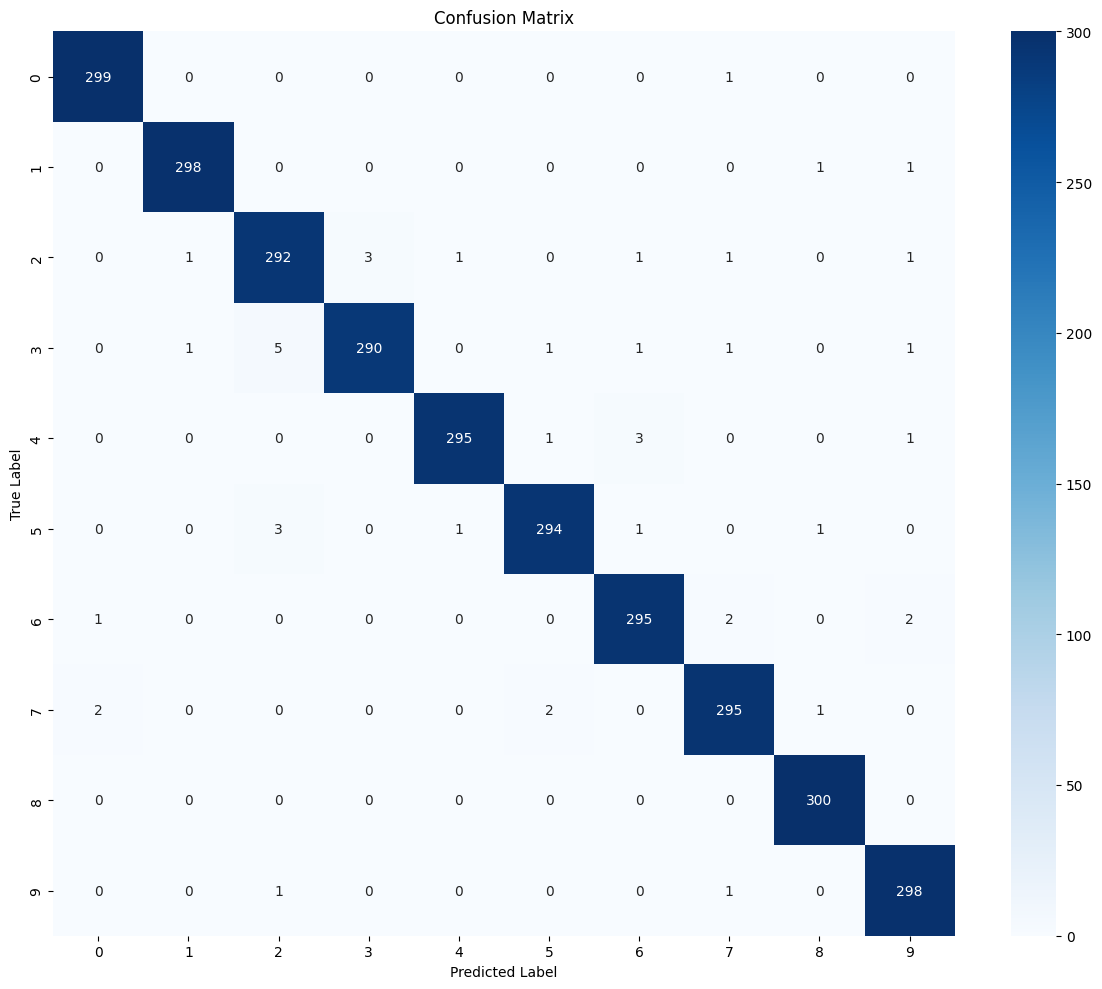

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

@torch.no_grad()
def plot_confusion_matrix(model, loader, device, class_names=None):
    model.eval()
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    if class_names is None:
        class_names = [str(i) for i in range(cm.shape[0])]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.tight_layout()

test_loss, test_acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss())
print(f"Best model test loss: {test_loss:.4f} | test acc: {test_acc:.4f}")
plot_confusion_matrix(best_model, test_loader, device)

Матрица ошибок на тестовой выборке показывает, что большинство цифр классифицируются почти без ошибок.  
Наибольшее число ошибок наблюдается для цифры 3 (5 примеров спутаны с 2) и 2 (3 примера спутаны с 3), что объяснимо: эти символы имеют схожую структуру.